# Product Detection Model Analysis

**Thesis:** Retail Inventory Audit System using Computer Vision

This notebook analyzes the trained YOLOv8 model performance for product detection.

## 1. Setup & Imports

In [ ]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import numpy as np

# Get project root (works from any location)
NOTEBOOK_DIR = Path().absolute()
if NOTEBOOK_DIR.name == 'notebooks':
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Paths
MODEL_DIR = PROJECT_ROOT / 'models/weights/product_detector'
DATA_DIR = PROJECT_ROOT / 'data/splits'

print(f"Project root: {PROJECT_ROOT}")
print(f"Model directory: {MODEL_DIR}")
print(f"Model exists: {MODEL_DIR.exists()}")
print(f"Data directory: {DATA_DIR}")

## 2. Training Results Analysis

In [2]:
# Load training results
results_df = pd.read_csv(MODEL_DIR / 'results.csv')
results_df.columns = results_df.columns.str.strip()

print(f"Total epochs: {len(results_df)}")
print(f"\nFinal metrics (Epoch {len(results_df)}):")
print(f"  mAP50: {results_df['metrics/mAP50(B)'].iloc[-1]:.4f}")
print(f"  mAP50-95: {results_df['metrics/mAP50-95(B)'].iloc[-1]:.4f}")
print(f"  Precision: {results_df['metrics/precision(B)'].iloc[-1]:.4f}")
print(f"  Recall: {results_df['metrics/recall(B)'].iloc[-1]:.4f}")

results_df.tail()

Total epochs: 50

Final metrics (Epoch 50):
  mAP50: 0.4971
  mAP50-95: 0.2800
  Precision: 0.4526
  Recall: 0.5293


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,92.4294,1.12341,1.44299,1.25605,0.51609,0.58512,0.49461,0.27598,1.37139,1.45631,1.32357,0.000136,0.000136,0.000136
46,47,93.3566,1.09038,1.51373,1.19712,0.51722,0.50914,0.49172,0.27802,1.34520,1.43972,1.31164,0.000111,0.000111,0.000111
47,48,94.2798,1.07454,1.52091,1.25936,0.44812,0.55115,0.49747,0.27858,1.34024,1.39890,1.30177,0.000087,0.000087,0.000087
48,49,95.1543,1.12772,1.43128,1.27077,0.42913,0.54894,0.49549,0.27912,1.34077,1.38147,1.29417,0.000062,0.000062,0.000062
49,50,96.0446,1.09056,1.37095,1.21732,0.45255,0.52933,0.49709,0.28001,1.35372,1.37293,1.29868,0.000037,0.000037,0.000037


### 2.1 Loss Curves

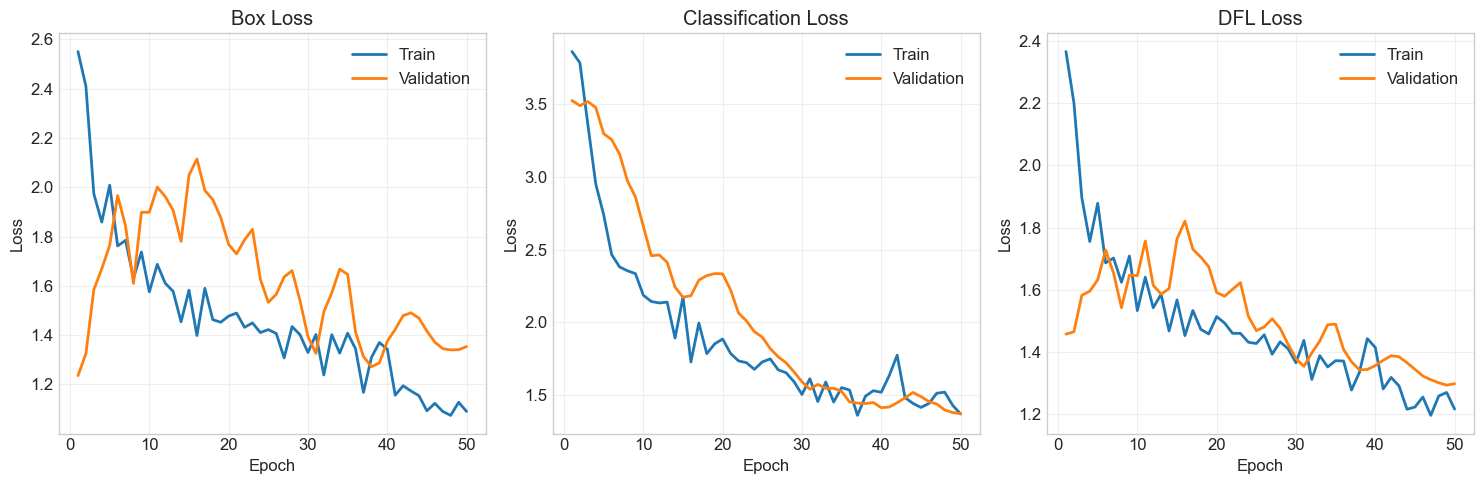

Saved: thesis_loss_curves.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box Loss
axes[0].plot(results_df['epoch'], results_df['train/box_loss'], label='Train', linewidth=2)
axes[0].plot(results_df['epoch'], results_df['val/box_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Box Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Classification Loss
axes[1].plot(results_df['epoch'], results_df['train/cls_loss'], label='Train', linewidth=2)
axes[1].plot(results_df['epoch'], results_df['val/cls_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Classification Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# DFL Loss
axes[2].plot(results_df['epoch'], results_df['train/dfl_loss'], label='Train', linewidth=2)
axes[2].plot(results_df['epoch'], results_df['val/dfl_loss'], label='Validation', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('DFL Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'thesis_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: thesis_loss_curves.png")

### 2.2 Performance Metrics

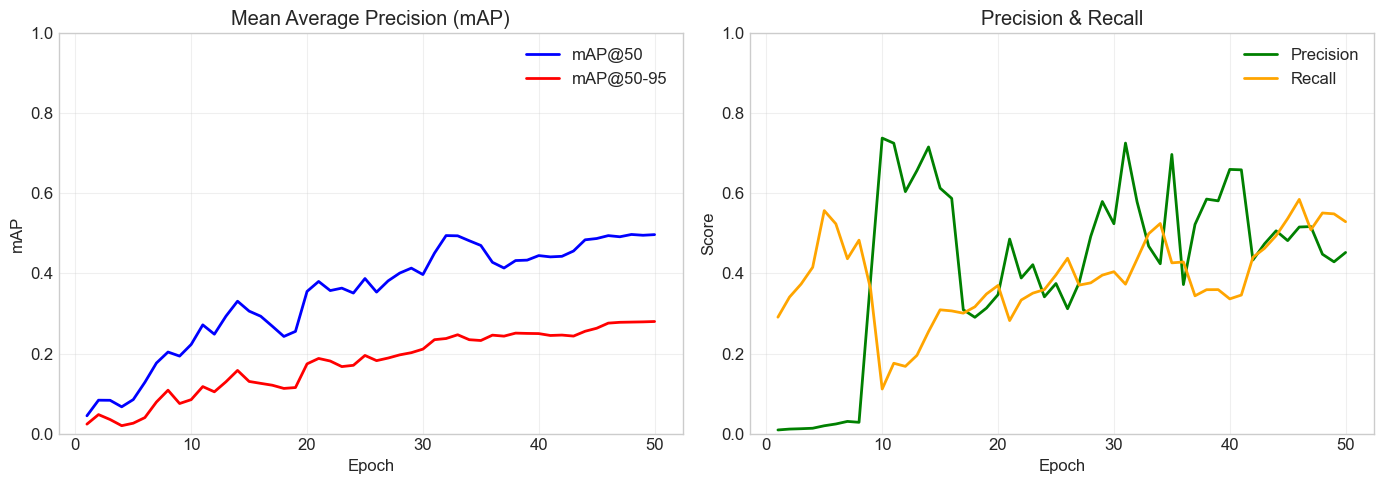

Saved: thesis_metrics_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# mAP curves
axes[0].plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP@50', linewidth=2, color='blue')
axes[0].plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP@50-95', linewidth=2, color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('mAP')
axes[0].set_title('Mean Average Precision (mAP)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Precision & Recall
axes[1].plot(results_df['epoch'], results_df['metrics/precision(B)'], label='Precision', linewidth=2, color='green')
axes[1].plot(results_df['epoch'], results_df['metrics/recall(B)'], label='Recall', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'thesis_metrics_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: thesis_metrics_curves.png")

## 3. Confusion Matrix Analysis

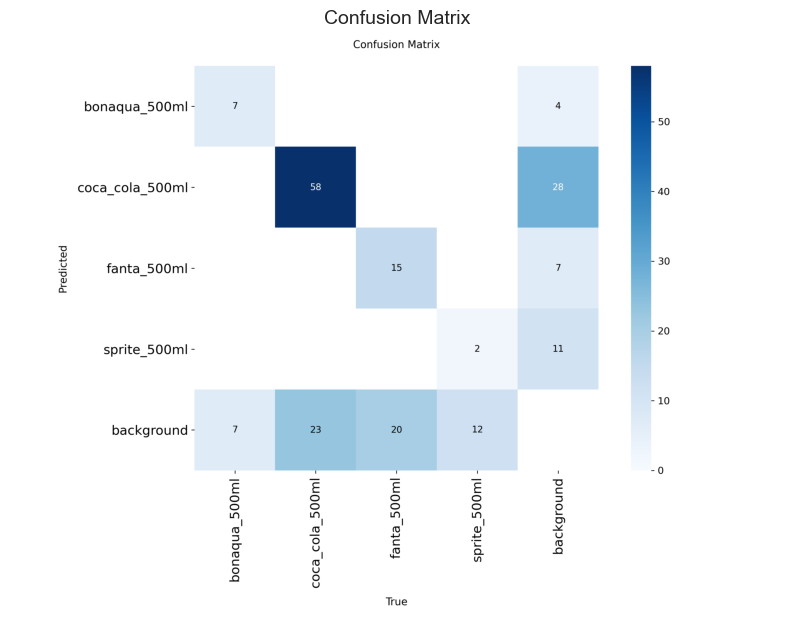

In [5]:
# Display confusion matrix
cm_path = MODEL_DIR / 'confusion_matrix.png'
if cm_path.exists():
    cm_img = Image.open(cm_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(cm_img)
    plt.axis('off')
    plt.title('Confusion Matrix', fontsize=14)
    plt.show()
else:
    print("Confusion matrix not found")

## 4. Dataset Statistics

In [6]:
# Count images in each split
splits = ['train', 'val', 'test']
image_counts = {}
label_counts = {}

for split in splits:
    img_dir = DATA_DIR / split / 'images'
    lbl_dir = DATA_DIR / split / 'labels'
    
    if img_dir.exists():
        images = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
        image_counts[split] = len(images)
    else:
        image_counts[split] = 0
        
    if lbl_dir.exists():
        labels = list(lbl_dir.glob('*.txt'))
        label_counts[split] = len(labels)
    else:
        label_counts[split] = 0

# Create summary table
dataset_summary = pd.DataFrame({
    'Split': splits,
    'Images': [image_counts[s] for s in splits],
    'Labels': [label_counts[s] for s in splits]
})

total_images = sum(image_counts.values())
dataset_summary['Percentage'] = dataset_summary['Images'] / total_images * 100

print("Dataset Summary:")
print(dataset_summary.to_string(index=False))
print(f"\nTotal images: {total_images}")

Dataset Summary:
Split  Images  Labels  Percentage
train      67      67   69.791667
  val      19      19   19.791667
 test      10      10   10.416667

Total images: 96


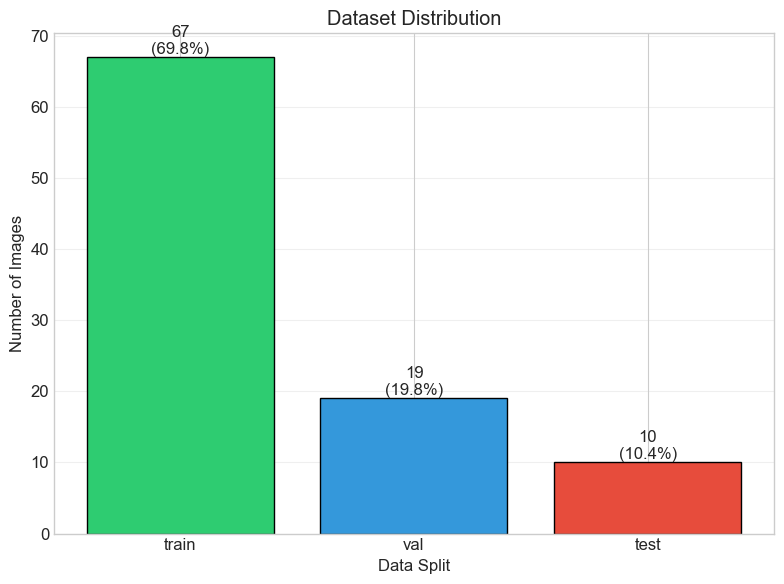

Saved: thesis_dataset_distribution.png


In [7]:
# Visualize dataset split
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(dataset_summary['Split'], dataset_summary['Images'], color=colors, edgecolor='black')

# Add value labels
for bar, pct in zip(bars, dataset_summary['Percentage']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12)

ax.set_xlabel('Data Split')
ax.set_ylabel('Number of Images')
ax.set_title('Dataset Distribution')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'thesis_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: thesis_dataset_distribution.png")

## 5. Class Distribution Analysis

In [8]:
# Class names
class_names = {
    0: 'bonaqua_500ml',
    1: 'coca_cola_500ml', 
    2: 'fanta_500ml',
    3: 'sprite_500ml'
}

# Count annotations per class
class_counts = {i: 0 for i in range(4)}

for split in ['train', 'val']:
    lbl_dir = DATA_DIR / split / 'labels'
    if lbl_dir.exists():
        for lbl_file in lbl_dir.glob('*.txt'):
            with open(lbl_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        if class_id in class_counts:
                            class_counts[class_id] += 1

# Create DataFrame
class_df = pd.DataFrame({
    'Class ID': list(class_names.keys()),
    'Class Name': list(class_names.values()),
    'Count': [class_counts[i] for i in range(4)]
})

print("Class Distribution:")
print(class_df.to_string(index=False))
print(f"\nTotal annotations: {sum(class_counts.values())}")

Class Distribution:
 Class ID      Class Name  Count
        0   bonaqua_500ml     74
        1 coca_cola_500ml    376
        2     fanta_500ml    171
        3    sprite_500ml     76

Total annotations: 697


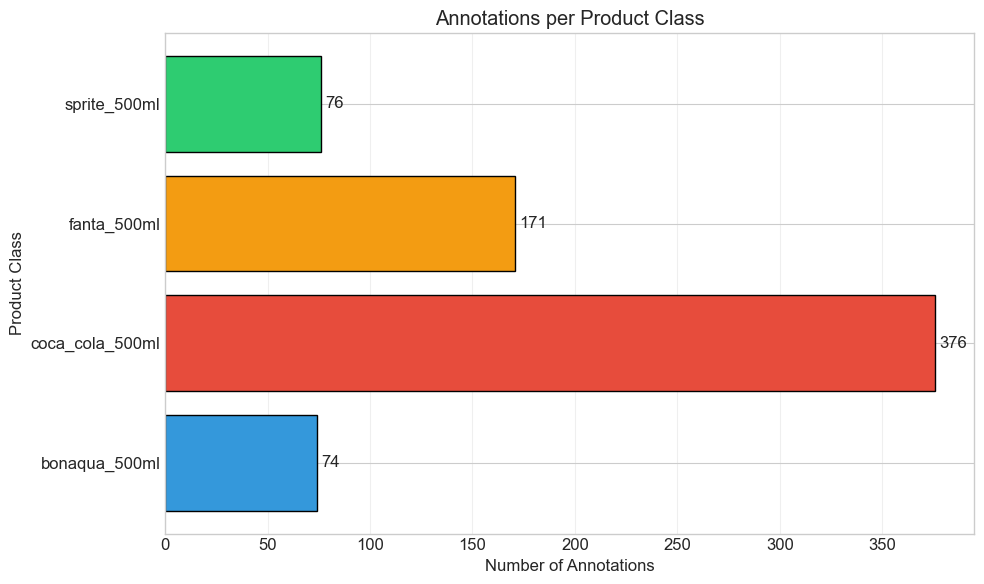

Saved: thesis_class_distribution.png


In [9]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
bars = ax.barh(class_df['Class Name'], class_df['Count'], color=colors, edgecolor='black')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}',
            ha='left', va='center', fontsize=12)

ax.set_xlabel('Number of Annotations')
ax.set_ylabel('Product Class')
ax.set_title('Annotations per Product Class')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'thesis_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: thesis_class_distribution.png")

## 6. Model Performance Summary

In [10]:
# Final performance summary
final_metrics = {
    'Metric': ['mAP@50', 'mAP@50-95', 'Precision', 'Recall'],
    'Value': [
        results_df['metrics/mAP50(B)'].iloc[-1],
        results_df['metrics/mAP50-95(B)'].iloc[-1],
        results_df['metrics/precision(B)'].iloc[-1],
        results_df['metrics/recall(B)'].iloc[-1]
    ]
}

metrics_df = pd.DataFrame(final_metrics)
metrics_df['Percentage'] = metrics_df['Value'] * 100

print("="*50)
print("FINAL MODEL PERFORMANCE")
print("="*50)
for _, row in metrics_df.iterrows():
    print(f"{row['Metric']:15} {row['Percentage']:6.2f}%")
print("="*50)

FINAL MODEL PERFORMANCE
mAP@50           49.71%
mAP@50-95        28.00%
Precision        45.26%
Recall           52.93%


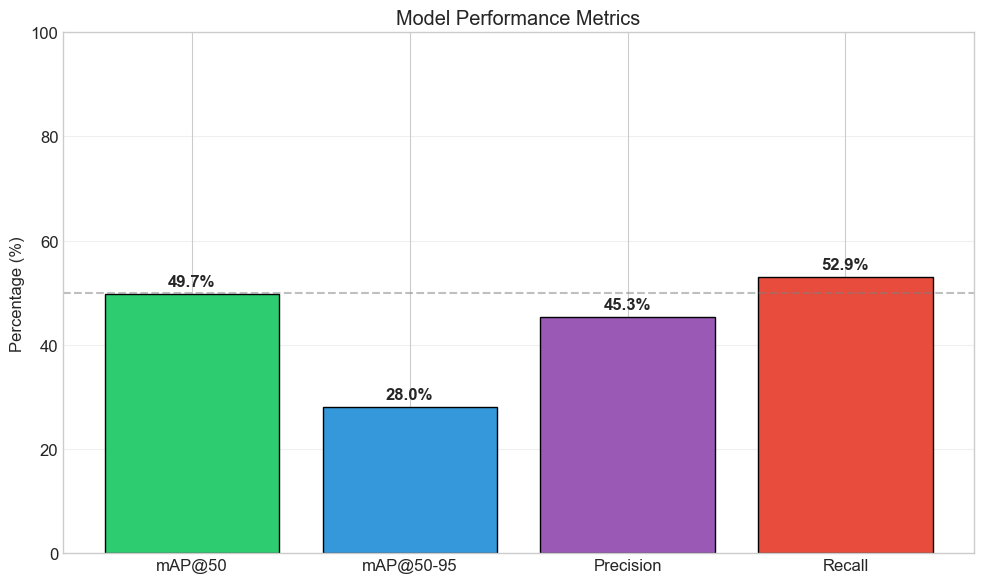

Saved: thesis_performance_summary.png


In [11]:
# Performance bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = ax.bar(metrics_df['Metric'], metrics_df['Percentage'], color=colors, edgecolor='black')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Percentage (%)')
ax.set_title('Model Performance Metrics')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'thesis_performance_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: thesis_performance_summary.png")

## 7. Training Configuration

In [12]:
import yaml

# Load training args
args_path = MODEL_DIR / 'args.yaml'
if args_path.exists():
    with open(args_path, 'r') as f:
        args = yaml.safe_load(f)
    
    # Key training parameters
    key_params = {
        'Model': args.get('model', 'N/A'),
        'Epochs': args.get('epochs', 'N/A'),
        'Batch Size': args.get('batch', 'N/A'),
        'Image Size': args.get('imgsz', 'N/A'),
        'Optimizer': args.get('optimizer', 'N/A'),
        'Learning Rate': args.get('lr0', 'N/A'),
        'Patience': args.get('patience', 'N/A'),
        'Mosaic': args.get('mosaic', 'N/A'),
        'Mixup': args.get('mixup', 'N/A'),
    }
    
    print("Training Configuration:")
    print("-" * 40)
    for key, value in key_params.items():
        print(f"{key:15} {value}")
else:
    print("args.yaml not found")

Training Configuration:
----------------------------------------
Model           yolov8n.pt
Epochs          50
Batch Size      16
Image Size      640
Optimizer       auto
Learning Rate   0.01
Patience        15
Mosaic          1.0
Mixup           0.1


## 8. Conclusions

### Key Findings:
1. **Model Performance**: mAP@50 = 49.7%, indicating room for improvement
2. **Class Imbalance**: Some classes have more training samples than others
3. **Convergence**: Loss curves show stable convergence without overfitting

### Recommendations for Improvement:
1. **Add more training images** - Target 200+ images total
2. **Balance class distribution** - Ensure equal samples per class
3. **Increase epochs** - Try 100-150 epochs
4. **Data augmentation** - Apply more aggressive augmentation